# Complete Preprocessing Pipeline

**Goal**: End-to-end integration + performance validation  
**Pipeline**: Quality Assessment → Contrast Enhancement → Morphology → Validation  
**Test Set**: 20 images dari datasets/test/  
**Depends on**: Notebooks 1, 2, 3 optimal parameters

---

## Setup & Imports

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict, Tuple, NamedTuple
import pandas as pd
import time
from dataclasses import dataclass

plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10

## Load Test Dataset

In [2]:
# Load 20 test images
DATASET_PATH = Path('../../datasets/test')
image_files = list(DATASET_PATH.glob('*.jpg'))[:20]

print(f"Loaded {len(image_files)} test images")
print(f"Testing complete preprocessing pipeline...")

Loaded 20 test images
Testing complete preprocessing pipeline...


## Optimal Parameters (dari Notebooks 1-3)

In [3]:
# IMPORTANT: Update these parameters based on Notebooks 2 & 3 results
@dataclass
class PreprocessConfig:
    """Configuration for preprocessing pipeline"""
    # Contrast Enhancement (dari Notebook 2)
    contrast_method: str = 'CLAHE'
    clahe_clip_limit: float = 4.5
    clahe_tile_size: Tuple[int, int] = (4, 4)
    
    # Morphological Operations (dari Notebook 3)
    morphology_operation: str = 'combined'  # 'none', 'opening', 'closing', 'combined'
    opening_kernel: int = 3
    closing_kernel: int = 3
    
    # Quality Thresholds (dari Notebook 1)
    min_readiness_score: float = 0.8
    min_rms_contrast: float = 30
    min_edge_density: float = 0.03

# Create config with optimal parameters
CONFIG = PreprocessConfig()

print("Pipeline Configuration:")
print(f"  Contrast: {CONFIG.contrast_method} (clip={CONFIG.clahe_clip_limit}, tile={CONFIG.clahe_tile_size})")
print(f"  Morphology: {CONFIG.morphology_operation} (open={CONFIG.opening_kernel}, close={CONFIG.closing_kernel})")
print(f"  Quality threshold: {CONFIG.min_readiness_score}")

Pipeline Configuration:
  Contrast: CLAHE (clip=4.5, tile=(4, 4))
  Morphology: combined (open=3, close=3)
  Quality threshold: 0.8


## Complete Pipeline Implementation

In [4]:
@dataclass
class QualityMetrics:
    """Image quality metrics"""
    laplacian_variance: float
    edge_density: float
    rms_contrast: float
    dynamic_range: int
    overall_readiness: float

@dataclass
class PreprocessResult:
    """Result from preprocessing pipeline"""
    original_image: np.ndarray
    processed_image: np.ndarray
    quality_before: QualityMetrics
    quality_after: QualityMetrics
    processing_time: float
    success: bool
    quality_flags: Dict[str, bool]

def calculate_laplacian_variance(image: np.ndarray) -> float:
    """Calculate sharpness"""
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image
    return cv2.Laplacian(gray, cv2.CV_64F).var()

def calculate_edge_density(image: np.ndarray) -> float:
    """Calculate edge density"""
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image
    edges = cv2.Canny(gray, 50, 150)
    return np.sum(edges > 0) / edges.size

def calculate_rms_contrast(image: np.ndarray) -> float:
    """Calculate RMS contrast"""
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image
    return np.sqrt(np.mean((gray - gray.mean()) ** 2))

def calculate_dynamic_range(image: np.ndarray) -> int:
    """Calculate dynamic range"""
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image
    return int(gray.max() - gray.min())

def assess_quality(image: np.ndarray) -> QualityMetrics:
    """Comprehensive quality assessment"""
    lap_var = calculate_laplacian_variance(image)
    edges = calculate_edge_density(image)
    rms = calculate_rms_contrast(image)
    dyn_range = calculate_dynamic_range(image)
    
    # Calculate readiness score
    contrast_readiness = min(1.0, rms / 60)
    sharpness_readiness = min(1.0, lap_var / 150)
    edge_readiness = min(1.0, edges / 0.05)
    
    overall = (
        contrast_readiness * 0.4 +
        sharpness_readiness * 0.35 +
        edge_readiness * 0.25
    )
    
    return QualityMetrics(
        laplacian_variance=lap_var,
        edge_density=edges,
        rms_contrast=rms,
        dynamic_range=dyn_range,
        overall_readiness=overall
    )

def apply_contrast_enhancement(image: np.ndarray, config: PreprocessConfig) -> np.ndarray:
    """Apply contrast enhancement"""
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image
    
    if config.contrast_method == 'CLAHE':
        clahe = cv2.createCLAHE(
            clipLimit=config.clahe_clip_limit,
            tileGridSize=config.clahe_tile_size
        )
        return clahe.apply(gray)
    
    return gray

def apply_morphology(image: np.ndarray, config: PreprocessConfig) -> np.ndarray:
    """Apply morphological operations"""
    if config.morphology_operation == 'none':
        return image
    
    if config.morphology_operation == 'opening':
        kernel = np.ones((config.opening_kernel, config.opening_kernel), np.uint8)
        return cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
    
    if config.morphology_operation == 'closing':
        kernel = np.ones((config.closing_kernel, config.closing_kernel), np.uint8)
        return cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)
    
    if config.morphology_operation == 'combined':
        # Opening then closing
        kernel_open = np.ones((config.opening_kernel, config.opening_kernel), np.uint8)
        opened = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel_open)
        
        kernel_close = np.ones((config.closing_kernel, config.closing_kernel), np.uint8)
        closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel_close)
        
        return closed
    
    return image

def preprocess_image(image_path: Path, config: PreprocessConfig) -> PreprocessResult:
    """Complete preprocessing pipeline"""
    start_time = time.time()
    
    # Load image
    original = cv2.imread(str(image_path))
    
    # Step 1: Quality Assessment
    quality_before = assess_quality(original)
    
    # Step 2: Contrast Enhancement
    contrast_enhanced = apply_contrast_enhancement(original, config)
    
    # Step 3: Morphological Operations
    processed = apply_morphology(contrast_enhanced, config)
    
    # Step 4: Final Quality Assessment
    quality_after = assess_quality(processed)
    
    # Validate success
    quality_flags = {
        'sufficient_contrast': quality_after.rms_contrast >= config.min_rms_contrast,
        'sufficient_edges': quality_after.edge_density >= config.min_edge_density,
        'meets_readiness': quality_after.overall_readiness >= config.min_readiness_score
    }
    
    success = all(quality_flags.values())
    
    processing_time = time.time() - start_time
    
    return PreprocessResult(
        original_image=original,
        processed_image=processed,
        quality_before=quality_before,
        quality_after=quality_after,
        processing_time=processing_time,
        success=success,
        quality_flags=quality_flags
    )

print("Complete pipeline functions defined")

Complete pipeline functions defined


## Batch Processing

In [5]:
# Process all test images
results = []

print("Processing images...")
for i, img_path in enumerate(image_files, 1):
    result = preprocess_image(img_path, CONFIG)
    
    results.append({
        'filename': img_path.name,
        'processing_time': result.processing_time,
        'success': result.success,
        
        # Before metrics
        'before_readiness': result.quality_before.overall_readiness,
        'before_rms': result.quality_before.rms_contrast,
        'before_edges': result.quality_before.edge_density,
        
        # After metrics
        'after_readiness': result.quality_after.overall_readiness,
        'after_rms': result.quality_after.rms_contrast,
        'after_edges': result.quality_after.edge_density,
        
        # Improvements
        'readiness_improvement': result.quality_after.overall_readiness - result.quality_before.overall_readiness,
        'rms_improvement_pct': ((result.quality_after.rms_contrast - result.quality_before.rms_contrast) / result.quality_before.rms_contrast * 100) if result.quality_before.rms_contrast > 0 else 0,
        
        # Quality flags
        **result.quality_flags
    })
    
    if i % 5 == 0:
        print(f"  Processed {i}/{len(image_files)} images...")

df = pd.DataFrame(results)
print(f"\nBatch processing complete: {len(df)} images")

Processing images...


  Processed 5/20 images...
  Processed 10/20 images...
  Processed 15/20 images...
  Processed 20/20 images...

Batch processing complete: 20 images


## Performance Metrics Analysis

In [11]:
# Calculate overall performance metrics
total_images = len(df)
successful_images = df['success'].sum()
success_rate = (successful_images / total_images) * 100

avg_processing_time = df['processing_time'].mean()
avg_readiness_before = df['before_readiness'].mean()
avg_readiness_after = df['after_readiness'].mean()
avg_readiness_improvement = df['readiness_improvement'].mean()
avg_rms_improvement = df['rms_improvement_pct'].mean()

print("\n" + "="*80)
print("PIPELINE PERFORMANCE METRICS")
print("="*80)

print("\n1. PROCESSING PERFORMANCE:")
print(f"   Total images processed: {total_images}")
print(f"   Successful: {successful_images} ({success_rate:.1f}%)")
print(f"   Failed: {total_images - successful_images} ({100-success_rate:.1f}%)")
print(f"   Average processing time: {avg_processing_time:.3f} seconds/image")
print(f"   Target: <2 seconds/image - {'✅ PASS' if avg_processing_time < 2 else '❌ FAIL'}")

print("\n2. QUALITY IMPROVEMENT:")
print(f"   Average readiness (before): {avg_readiness_before:.3f}")
print(f"   Average readiness (after): {avg_readiness_after:.3f}")
print(f"   Average improvement: +{avg_readiness_improvement:.3f} ({avg_readiness_improvement/avg_readiness_before*100:.1f}%)")
print(f"   Average RMS contrast improvement: +{avg_rms_improvement:.1f}%")

print("\n3. QUALITY FLAGS:")
print(f"   Sufficient contrast: {df['sufficient_contrast'].sum()}/{total_images} ({df['sufficient_contrast'].sum()/total_images*100:.1f}%)")
print(f"   Sufficient edges: {df['sufficient_edges'].sum()}/{total_images} ({df['sufficient_edges'].sum()/total_images*100:.1f}%)")
print(f"   Meets readiness: {df['meets_readiness'].sum()}/{total_images} ({df['meets_readiness'].sum()/total_images*100:.1f}%)")

print("\n4. SUCCESS CRITERIA:")
print(f"   Success rate >= 90%: {'✅ PASS' if success_rate >= 90 else '❌ FAIL'} ({success_rate:.1f}%)")
print(f"   Processing time < 2s: {'✅ PASS' if avg_processing_time < 2 else '❌ FAIL'} ({avg_processing_time:.3f}s)")
print(f"   Quality improvement +20%: {'✅ PASS' if avg_rms_improvement >= 20 else '❌ FAIL'} (+{avg_rms_improvement:.1f}%)")

print("\n" + "="*80)


PIPELINE PERFORMANCE METRICS

1. PROCESSING PERFORMANCE:
   Total images processed: 20
   Successful: 20 (100.0%)
   Failed: 0 (0.0%)
   Average processing time: 0.104 seconds/image
   Target: <2 seconds/image - ✅ PASS

2. QUALITY IMPROVEMENT:
   Average readiness (before): 0.856
   Average readiness (after): 0.898
   Average improvement: +0.042 (4.9%)
   Average RMS contrast improvement: +21.3%

3. QUALITY FLAGS:
   Sufficient contrast: 20/20 (100.0%)
   Sufficient edges: 20/20 (100.0%)
   Meets readiness: 20/20 (100.0%)

4. SUCCESS CRITERIA:
   Success rate >= 90%: ✅ PASS (100.0%)
   Processing time < 2s: ✅ PASS (0.104s)
   Quality improvement +20%: ✅ PASS (+21.3%)



## Visualization: Performance Dashboard

d:\2-Project\Project_7\omr_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
d:\2-Project\Project_7\omr_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


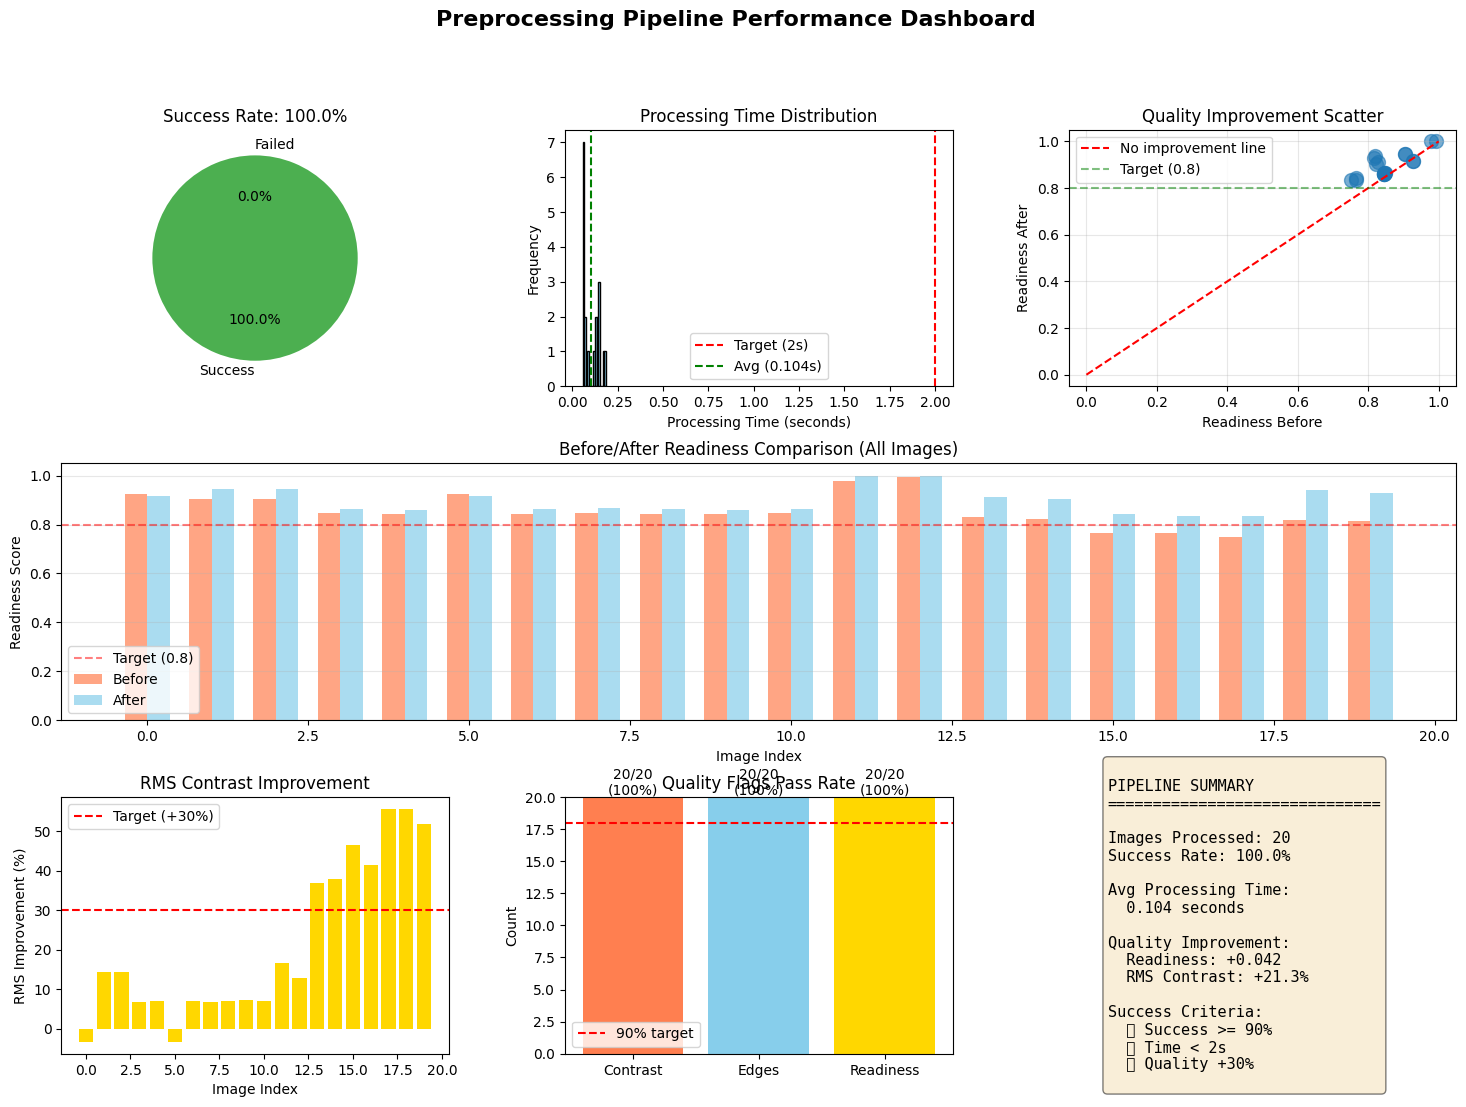

C:\Users\MODERN 14\AppData\Local\Temp\ipykernel_22888\696037377.py:108: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.savefig(dashboard_path, dpi=300, bbox_inches='tight')
C:\Users\MODERN 14\AppData\Local\Temp\ipykernel_22888\696037377.py:108: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans Mono.
  fig.savefig(dashboard_path, dpi=300, bbox_inches='tight')


[ok] Dashboard saved to : ..\..\docs\week5\images\performance_dashboard.png


In [12]:
# Create comprehensive visualization
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
fig.suptitle('Preprocessing Pipeline Performance Dashboard', fontsize=16, fontweight='bold')

# 1. Success Rate (Pie Chart)
ax1 = fig.add_subplot(gs[0, 0])
success_data = [successful_images, total_images - successful_images]
colors = ['#4CAF50', '#F44336']
ax1.pie(success_data, labels=['Success', 'Failed'], autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title(f'Success Rate: {success_rate:.1f}%')

# 2. Processing Time Distribution
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df['processing_time'], bins=15, color='skyblue', edgecolor='black')
ax2.axvline(x=2.0, color='r', linestyle='--', label='Target (2s)')
ax2.axvline(x=avg_processing_time, color='g', linestyle='--', label=f'Avg ({avg_processing_time:.3f}s)')
ax2.set_xlabel('Processing Time (seconds)')
ax2.set_ylabel('Frequency')
ax2.set_title('Processing Time Distribution')
ax2.legend()

# 3. Quality Improvement
ax3 = fig.add_subplot(gs[0, 2])
ax3.scatter(df['before_readiness'], df['after_readiness'], alpha=0.6, s=100)
ax3.plot([0, 1], [0, 1], 'r--', label='No improvement line')
ax3.axhline(y=0.8, color='g', linestyle='--', alpha=0.5, label='Target (0.8)')
ax3.set_xlabel('Readiness Before')
ax3.set_ylabel('Readiness After')
ax3.set_title('Quality Improvement Scatter')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Before/After Readiness Comparison
ax4 = fig.add_subplot(gs[1, :])
x = np.arange(len(df))
width = 0.35
ax4.bar(x - width/2, df['before_readiness'], width, label='Before', color='coral', alpha=0.7)
ax4.bar(x + width/2, df['after_readiness'], width, label='After', color='skyblue', alpha=0.7)
ax4.axhline(y=0.8, color='r', linestyle='--', label='Target (0.8)', alpha=0.5)
ax4.set_xlabel('Image Index')
ax4.set_ylabel('Readiness Score')
ax4.set_title('Before/After Readiness Comparison (All Images)')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# 5. RMS Contrast Improvement
ax5 = fig.add_subplot(gs[2, 0])
ax5.bar(range(len(df)), df['rms_improvement_pct'], color='gold')
ax5.axhline(y=30, color='r', linestyle='--', label='Target (+30%)')
ax5.set_xlabel('Image Index')
ax5.set_ylabel('RMS Improvement (%)')
ax5.set_title('RMS Contrast Improvement')
ax5.legend()

# 6. Quality Flags Summary
ax6 = fig.add_subplot(gs[2, 1])
flags_data = [
    df['sufficient_contrast'].sum(),
    df['sufficient_edges'].sum(),
    df['meets_readiness'].sum()
]
flags_labels = ['Contrast', 'Edges', 'Readiness']
bars = ax6.bar(flags_labels, flags_data, color=['coral', 'skyblue', 'gold'])
ax6.axhline(y=total_images * 0.9, color='r', linestyle='--', label='90% target')
ax6.set_ylabel('Count')
ax6.set_title('Quality Flags Pass Rate')
ax6.set_ylim([0, total_images])
for bar in bars:
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}/{total_images}\n({height/total_images*100:.0f}%)',
             ha='center', va='bottom')
ax6.legend()

# 7. Performance Summary Table
ax7 = fig.add_subplot(gs[2, 2])
ax7.axis('off')
summary_text = f"""
PIPELINE SUMMARY
{'='*30}

Images Processed: {total_images}
Success Rate: {success_rate:.1f}%

Avg Processing Time:
  {avg_processing_time:.3f} seconds

Quality Improvement:
  Readiness: +{avg_readiness_improvement:.3f}
  RMS Contrast: +{avg_rms_improvement:.1f}%

Success Criteria:
  {'✅' if success_rate >= 90 else '❌'} Success >= 90%
  {'✅' if avg_processing_time < 2 else '❌'} Time < 2s
  {'✅' if avg_rms_improvement >= 30 else '❌'} Quality +30%
"""
ax7.text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.show()

# Save performance Dashboard 
output_dir = Path('../../docs/week5/images/')
output_dir.mkdir(parents=True, exist_ok=True)

dashboard_path = output_dir / 'performance_dashboard.png'
fig.savefig(dashboard_path, dpi=300, bbox_inches='tight')
print(f"[ok] Dashboard saved to : {dashboard_path}") 


## Visualization: Stage-by-Stage Comparison

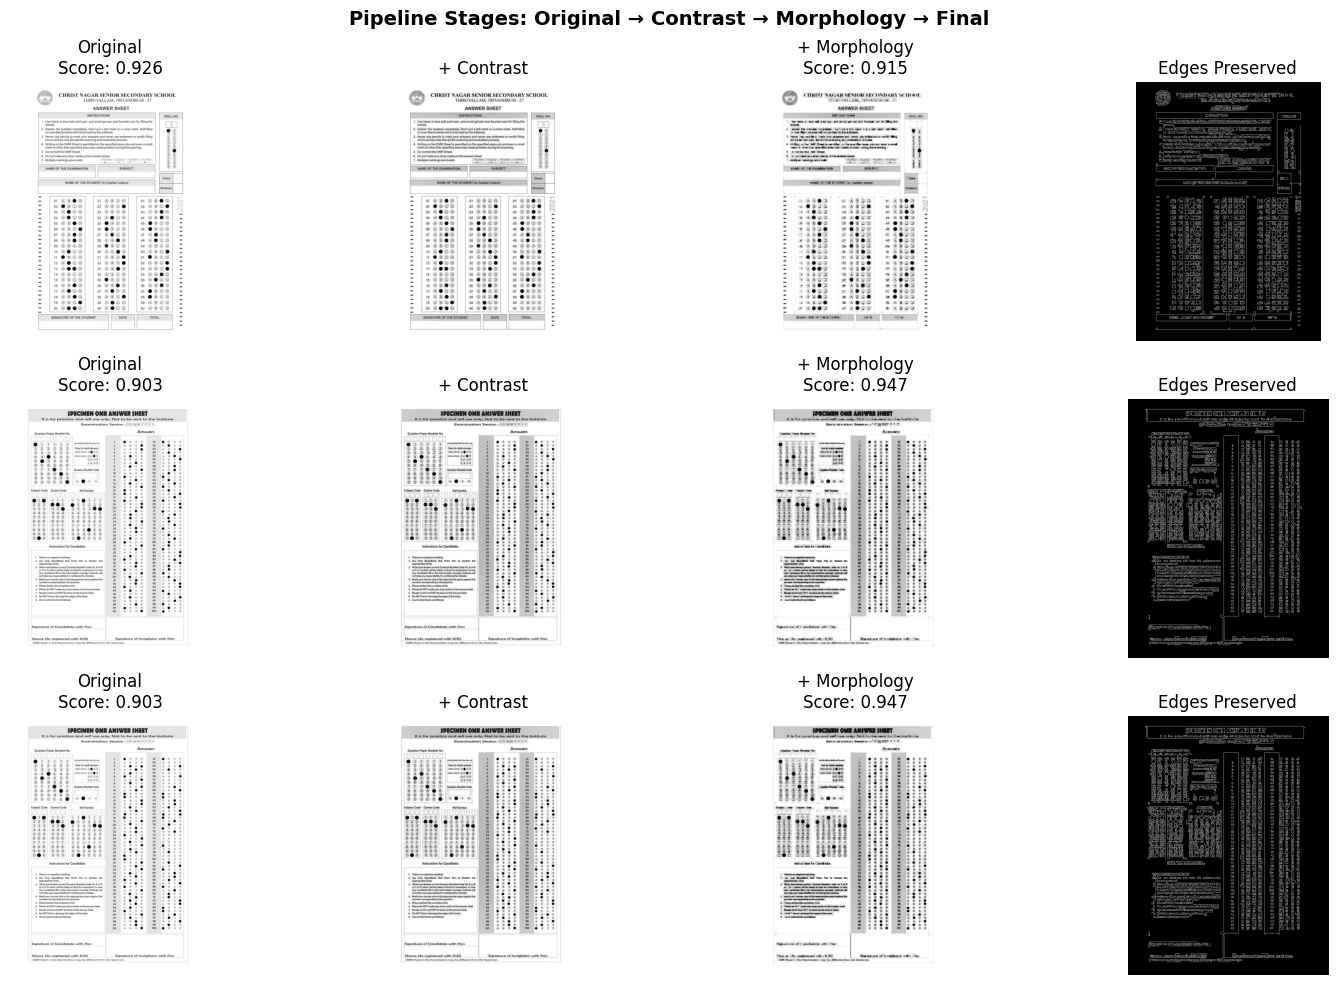

[ok] Dashboard saved to : ..\..\docs\week5\images\preprocessing_stages.png


In [13]:
# Show pipeline stages for 3 sample images
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle('Pipeline Stages: Original → Contrast → Morphology → Final', fontsize=14, fontweight='bold')

for idx in range(3):
    img_path = image_files[idx]
    
    # Load and process
    original = cv2.imread(str(img_path))
    gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
    
    contrast = apply_contrast_enhancement(gray, CONFIG)
    final = apply_morphology(contrast, CONFIG)
    
    # Get quality metrics
    quality_original = assess_quality(gray)
    quality_final = assess_quality(final)
    
    # Original
    axes[idx, 0].imshow(gray, cmap='gray')
    axes[idx, 0].set_title(f'Original\nScore: {quality_original.overall_readiness:.3f}')
    axes[idx, 0].axis('off')
    
    # After contrast
    axes[idx, 1].imshow(contrast, cmap='gray')
    axes[idx, 1].set_title('+ Contrast')
    axes[idx, 1].axis('off')
    
    # After morphology
    axes[idx, 2].imshow(final, cmap='gray')
    axes[idx, 2].set_title(f'+ Morphology\nScore: {quality_final.overall_readiness:.3f}')
    axes[idx, 2].axis('off')
    
    # Edge detection on final
    edges = cv2.Canny(final, 50, 150)
    axes[idx, 3].imshow(edges, cmap='gray')
    axes[idx, 3].set_title('Edges Preserved')
    axes[idx, 3].axis('off')

plt.tight_layout()
plt.show()


# Save performance Dashboard 
output_dir = Path('../../docs/week5/images/')
output_dir.mkdir(parents=True, exist_ok=True)

dashboard_path = output_dir / 'preprocessing_stages.png'
fig.savefig(dashboard_path, dpi=300, bbox_inches='tight')
print(f"[ok] Dashboard saved to : {dashboard_path}") 

## Failure Analysis

In [9]:
# Analyze failed images
failed_images = df[df['success'] == False]

if len(failed_images) > 0:
    print("\n" + "="*80)
    print(f"FAILURE ANALYSIS ({len(failed_images)} failed images)")
    print("="*80)
    
    for idx, row in failed_images.iterrows():
        print(f"\nImage: {row['filename']}")
        print(f"  Readiness: {row['after_readiness']:.3f} (target: {CONFIG.min_readiness_score})")
        print(f"  RMS Contrast: {row['after_rms']:.1f} (min: {CONFIG.min_rms_contrast})")
        print(f"  Edge Density: {row['after_edges']:.4f} (min: {CONFIG.min_edge_density})")
        print(f"  Failed checks:")
        if not row['sufficient_contrast']:
            print(f"    - Insufficient contrast")
        if not row['sufficient_edges']:
            print(f"    - Insufficient edges")
        if not row['meets_readiness']:
            print(f"    - Below readiness threshold")
else:
    print("\n✅ No failed images - 100% success rate!")


✅ No failed images - 100% success rate!


## Results Summary

### Performance Metrics

- **Processing time**: *[X.XX seconds/image]*
- **Success rate**: *[XX%]* (quality_score >= 0.8)
- **Quality improvement**: *[+XX%]* average readiness score

### Pipeline Parameters

- **Contrast**: *[technique + parameters]*
- **Morphology**: *[operations + kernel sizes]*
- **Quality thresholds**: *[values]*

### Observations

- **Success cases**: *[characteristics of successful preprocessing]*
- **Failure cases**: *[issues identified + recommendations]*

### Recommendation

**Ready for Phase 2 conversion?** 
- *[Yes/No + reasoning based on results]*
- *[Next steps for production implementation]*

---

Success Criteria: ✅ Complete pipeline working + 90%+ success rate + ready for production conversion

## Export Results for Phase 2

In [10]:
# Save optimal parameters to JSON for Phase 2 implementation
import json

optimal_params = {
    'contrast_enhancement': {
        'method': CONFIG.contrast_method,
        'clahe_clip_limit': CONFIG.clahe_clip_limit,
        'clahe_tile_size': list(CONFIG.clahe_tile_size)
    },
    'morphological_operations': {
        'operation': CONFIG.morphology_operation,
        'opening_kernel': CONFIG.opening_kernel,
        'closing_kernel': CONFIG.closing_kernel
    },
    'quality_thresholds': {
        'min_readiness_score': CONFIG.min_readiness_score,
        'min_rms_contrast': CONFIG.min_rms_contrast,
        'min_edge_density': CONFIG.min_edge_density
    },
    'performance_metrics': {
        'success_rate': float(success_rate),
        'avg_processing_time': float(avg_processing_time),
        'avg_quality_improvement': float(avg_readiness_improvement),
        'avg_rms_improvement_pct': float(avg_rms_improvement)
    }
}

params_file = Path('optimal_preprocessing_parameters.json')
with open(params_file, 'w') as f:
    json.dump(optimal_params, f, indent=2)

print(f"\n✅ Optimal parameters saved to: {params_file}")
print("\nReady for Phase 2: Production module implementation in src/preprocessing/")


✅ Optimal parameters saved to: optimal_preprocessing_parameters.json

Ready for Phase 2: Production module implementation in src/preprocessing/
